# 05 — Noisy Repetition-Code Decoder

**Background reading:**

- [Arthur Pesah's blog](https://arthurpesah.me/blog/) — accessible QEC explainers
- [QEC-Tutorials](https://github.com/entropicalabs/QEC-Tutorials/tree/main) — related tutorial material
- [Stim](https://github.com/quantumlib/Stim) — the stabilizer-circuit simulator used throughout this repository

## Learning objectives

Notebooks 03 and 04 built the syndrome-extraction machinery for the 3-qubit bit-flip code under a single, hand-picked error. This notebook asks a more realistic question: what happens when *every* physical qubit has some independent probability of flipping? By the end you should be able to:

1. simulate independent $X$ (bit-flip) noise on the 3-qubit repetition code with Stim;
2. apply an explicit syndrome lookup-table decoder to noisy measurement data;
3. compare the physical error probability $p$ with the resulting logical failure probability $p_L$ across a range of $p$, and plot the result;
4. explain why the code only helps below a certain noise level, and hurts above it;
5. explain why this same code offers no protection against phase-flip ($Z$) errors.

**Expected outputs:** a table and one plot of $p_L$ vs. $p$, and a short demonstration that $Z$ errors are invisible to this code's syndromes.

**Assumes:** `02_classical_3bit_repetition_code.ipynb` (syndrome, decode, code distance) and `03_stabilizers_and_syndromes.ipynb` / `04_syndrome_detection_circuits.ipynb` (stabilizers $Z_0Z_1, Z_1Z_2$, ancilla-based syndrome extraction, lookup-table decoding). Neither of those notebooks is modified here.

**How to use this notebook:** run cells in order. Before a cell marked **Prediction**, stop and write down your own answer first.

## 1. Independent noise, simulated with Stim

So far every error was hand-picked: "apply $X$ to qubit 0." Real qubits fail on their own, independently, with some probability $p$ per qubit. Stim models this directly with the `X_ERROR(p)` instruction: applied to a qubit, it flips that qubit with probability $p$ and does nothing with probability $1-p$, sampled fresh on every shot.

We reuse notebook 04's exact ancilla circuit (qubits 0–2 data, qubit 3 the $Z_0Z_1$ ancilla, qubit 4 the $Z_1Z_2$ ancilla), but replace the hand-picked `X` error with `X_ERROR(p)` on all three data qubits, and additionally measure the data qubits so we can *check*, in simulation, whether the decoder's final answer was right. (A real device cannot peek at the data qubits without destroying them — this measurement is a simulation-only tool for scoring the decoder, exactly as notebook 02's `logical_error_rate` scored its classical decoder against the bits it generated.)

In [1]:
import numpy as np
import stim


def noisy_syndrome_circuit(p):
    """Encode |0_L> = |000>, apply independent X_ERROR(p) to each data qubit,
    measure the Z0Z1/Z1Z2 ancillas, then measure the data qubits (for scoring only).
    """
    circuit = stim.Circuit()
    circuit.append("X_ERROR", [0, 1, 2], p)
    circuit.append("CX", [0, 3])
    circuit.append("CX", [1, 3])
    circuit.append("CX", [1, 4])
    circuit.append("CX", [2, 4])
    circuit.append("M", [3, 4, 0, 1, 2])
    return circuit


print(noisy_syndrome_circuit(0.1))

X_ERROR(0.1) 0 1 2
CX 0 3 1 3 1 4 2 4
M 3 4 0 1 2


## 2. An explicit syndrome lookup-table decoder

The decoder is the same table used in notebooks 02–04, now applied bit-by-bit to noisy data:

| Syndrome $(s_0, s_1)$ | Inferred flipped qubit |
|---|---|
| $(0, 0)$ | none |
| $(1, 0)$ | qubit 0 |
| $(1, 1)$ | qubit 1 |
| $(0, 1)$ | qubit 2 |

Decoding a shot means: read the syndrome, flip the inferred qubit (if any) in the measured data, then read out the logical bit by majority vote over the (corrected) three data bits. Since we always encode $|0_L\rangle$, a logical failure is simply a decoded bit of `1`.

In [2]:
SYNDROME_TABLE = {(0, 0): None, (1, 0): 0, (1, 1): 1, (0, 1): 2}


def logical_failure_rate(p, shots=20_000):
    """Run `shots` independent trials at physical error rate `p` and return the fraction
    that decode to the wrong logical bit.
    """
    samples = noisy_syndrome_circuit(p).compile_sampler().sample(shots=shots)
    syndromes = samples[:, 0:2].astype(int)
    data = samples[:, 2:5].astype(int).copy()

    for (s0, s1), flip_qubit in SYNDROME_TABLE.items():
        if flip_qubit is None:
            continue
        match = (syndromes[:, 0] == s0) & (syndromes[:, 1] == s1)
        data[match, flip_qubit] ^= 1

    decoded_bit = (data.sum(axis=1) >= 2).astype(int)
    return float(decoded_bit.mean())


print("p=0.05 ->", logical_failure_rate(0.05))
print("p=0.30 ->", logical_failure_rate(0.30))

p=0.05 -> 0.0067
p=0.30 -> 0.216


### Prediction 1

**Before running the cell above (or having just seen its output):** for $p = 0.05$, do you expect $p_L$ (logical failure probability) to be smaller or larger than $p$ itself? Roughly how much smaller/larger, given that the code corrects any *single*-qubit flip but not two or more (notebook 02, code distance 3)?

## 3. Physical vs. logical failure probability across a range of $p$

Now sweep $p$ over a small, sensible range and compare $p_L$ against $p$ itself (the "no code, one bare physical qubit" baseline).

In [3]:
probabilities = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
failure_rates = [logical_failure_rate(p) for p in probabilities]

header = f"{'p (physical)':>13} {'p_L (logical)':>15} {'helps?':>8}"
print(header)
print("-" * len(header))
for p, p_l in zip(probabilities, failure_rates):
    print(f"{p:>13.2f} {p_l:>15.4f} {str(p_l < p):>8}")

 p (physical)   p_L (logical)   helps?
--------------------------------------
         0.01          0.0003     True
         0.05          0.0067     True
         0.10          0.0306     True
         0.15          0.0634     True
         0.20          0.1029     True
         0.30          0.2132     True
         0.40          0.3566     True
         0.50          0.5030    False


### Prediction 2

**Before running the plot cell below:** across the range $p \in [0.01, 0.5]$, does the code help ($p_L < p$) for every value in this range, or does that stop being true somewhere? If it stops, roughly where do you expect the crossover to be?

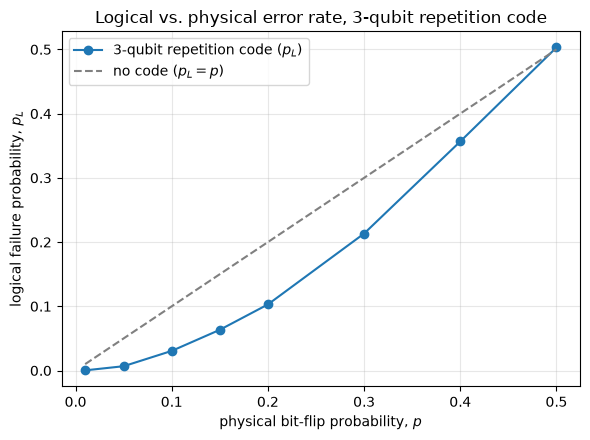

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(probabilities, failure_rates, marker="o", label="3-qubit repetition code ($p_L$)")
ax.plot(probabilities, probabilities, linestyle="--", color="gray", label="no code ($p_L = p$)")
ax.set_xlabel("physical bit-flip probability, $p$")
ax.set_ylabel("logical failure probability, $p_L$")
ax.set_title("Logical vs. physical error rate, 3-qubit repetition code")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Why the code only helps below a certain noise level

The repetition code corrects a shot only if at most one of the three data qubits flipped; it fails whenever two or three flip. For independent flips at rate $p$:

$$p_L = \underbrace{3p^2(1-p)}_{\text{exactly 2 flips}} + \underbrace{p^3}_{\text{all 3 flip}} = 3p^2 - 2p^3.$$

This is below the dashed $p_L = p$ line whenever $p < 0.5$, crosses it exactly at $p = 0.5$, and rises above it for $p > 0.5$. Intuitively: redundancy only helps if a *single* qubit is more likely to be right than wrong to begin with. Once each physical qubit is already flipping more than half the time, "voting" among three such qubits amplifies the error instead of correcting it — the majority is now more likely to be wrong. This is the simplest example of a broader QEC fact: every code has a noise threshold, and adding redundancy is only worthwhile below it.

## 5. Why this code does not protect against phase errors

Every stabilizer used here, $Z_0Z_1$ and $Z_1Z_2$, is built purely from $Z$ operators. Two $Z$-type operators **always commute**, on any qubits, because both are diagonal in the computational basis. Consequently *any* error that is itself a product of $Z$'s — a single $Z$ error, several at once, any combination — automatically commutes with both stabilizers. By notebook 03's anticommutation argument, a commuting error never flips a syndrome bit. The syndrome is `(0, 0)` no matter how many qubits suffered a $Z$ error: **this code cannot detect phase-flip errors at all.**

That does not mean $Z$ errors are harmless. On a genuine superposition such as $|+_L\rangle = \frac{1}{\sqrt{2}}(|000\rangle + |111\rangle)$, a single $Z$ error flips the *relative phase* between the $|000\rangle$ and $|111\rangle$ components, turning $|+_L\rangle$ into $|-_L\rangle = \frac{1}{\sqrt{2}}(|000\rangle - |111\rangle)$ — a different, distinguishable logical state — while every stabilizer keeps reporting "no error."

### Prediction 3

**Before running the next cell:** for the state $|+_L\rangle$ with a single $Z_0$ error applied, do you expect the $Z_0Z_1$/$Z_1Z_2$ syndrome to change? Do you expect the *logical* state to change?

In [5]:
# Reusing notebook 03's Pauli-matrix machinery to make the claim concrete.
X = np.array([[0, 1], [1, 0]])
Z = np.array([[1, 0], [0, -1]])
I2 = np.eye(2)


def single_qubit_op(op, qubit, n_qubits=3):
    mats = [I2] * n_qubits
    mats[qubit] = op
    result = mats[0]
    for m in mats[1:]:
        result = np.kron(result, m)
    return result


def three_qubit_op(op, qubit):
    return single_qubit_op(op, qubit, n_qubits=3)


def kron_all(*mats):
    result = mats[0]
    for m in mats[1:]:
        result = np.kron(result, m)
    return result


def eigenvalue(op, state):
    return float(np.real(state @ (op @ state)))


ket0, ket1 = np.array([1, 0]), np.array([0, 1])
state_000, state_111 = kron_all(ket0, ket0, ket0), kron_all(ket1, ket1, ket1)
plus_L = (state_000 + state_111) / np.sqrt(2)

Z0Z1 = three_qubit_op(Z, 0) @ three_qubit_op(Z, 1)
Z1Z2 = three_qubit_op(Z, 1) @ three_qubit_op(Z, 2)
X_L = three_qubit_op(X, 0) @ three_qubit_op(X, 1) @ three_qubit_op(X, 2)  # distinguishes +L / -L

after_Z0_error = three_qubit_op(Z, 0) @ plus_L

print("Before the Z0 error:")
print("  Z0Z1:", eigenvalue(Z0Z1, plus_L), " Z1Z2:", eigenvalue(Z1Z2, plus_L), " X_L:", eigenvalue(X_L, plus_L))
print("After the Z0 error:")
print("  Z0Z1:", eigenvalue(Z0Z1, after_Z0_error), " Z1Z2:", eigenvalue(Z1Z2, after_Z0_error), " X_L:", eigenvalue(X_L, after_Z0_error))

Before the Z0 error:
  Z0Z1: 0.9999999999999998  Z1Z2: 0.9999999999999998  X_L: 0.9999999999999998
After the Z0 error:
  Z0Z1: 0.9999999999999998  Z1Z2: 0.9999999999999998  X_L: -0.9999999999999998


Both stabilizer eigenvalues stay at $+1$ — the syndrome is silently `(0, 0)`, exactly as if nothing happened — while the $X_L$ eigenvalue flips from $+1$ to $-1$, confirming the state actually changed, undetected. A code that protects against both bit- and phase-flip errors (e.g. Shor's 9-qubit code, or the surface code in the next notebooks) needs a *second* family of stabilizers built from $X$'s to catch exactly this.

## 6. TODO exercises

**TODO 1:** Pick one probability, e.g. $p = 0.25$, and compare `logical_failure_rate(0.25)` against the exact analytic formula $3p^2 - 2p^3$ from Section 4. They should agree to within ordinary sampling noise (try increasing `shots` if they don't look close enough).

In [6]:
# TODO: compute both the simulated and the analytic logical failure rate at p = 0.25 and print them.
# p = 0.25
# simulated = logical_failure_rate(p, shots=50_000)
# analytic = 3 * p**2 - 2 * p**3
# print(simulated, analytic)


**TODO 2:** Section 5 showed a *single* $Z$ error is invisible to the syndrome. Confirm this also holds for *two* simultaneous $Z$ errors: apply `three_qubit_op(Z, 0) @ three_qubit_op(Z, 2) @ plus_L` and print the $Z_0Z_1$ and $Z_1Z_2$ eigenvalues. Do they still read $(+1, +1)$?

In [7]:
# TODO: build the state after Z0 AND Z2 errors, then print eigenvalue(Z0Z1, ...) and eigenvalue(Z1Z2, ...).
# after_two_Z_errors = three_qubit_op(Z, 0) @ three_qubit_op(Z, 2) @ plus_L
# print(eigenvalue(Z0Z1, after_two_Z_errors), eigenvalue(Z1Z2, after_two_Z_errors))


## 7. Closed-notebook recall checklist

Close this notebook (or at least stop scrolling up) and answer these from memory:

1. What does `X_ERROR(p)` do in a Stim circuit?
2. In your own words, what does the syndrome lookup-table decoder do with a noisy syndrome?
3. At roughly what physical error rate does this code stop helping, and why?
4. Why can $Z_0Z_1$ and $Z_1Z_2$ never detect a $Z$-type error?
5. What would a code need, beyond $Z_0Z_1$ and $Z_1Z_2$, to also catch phase-flip errors?

If any of these feel shaky, re-read the matching section above before moving on.

## My Notes and Answers

<!-- PROTECTED:BEGIN -->
**This section is owned by the notebook's author. Automated edits (including future AI-assisted notebook updates) must not alter or remove anything between the PROTECTED markers below.**

### Prediction 1

*(your answer here)*

### Prediction 2

*(your answer here)*

### Prediction 3

*(your answer here)*

### TODO 1 notes

*(your answer here)*

### TODO 2 notes

*(your answer here)*

### Closed-notebook checklist answers

1.
2.
3.
4.
5.

<!-- PROTECTED:END -->